# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


dataset yang digunakan bernama **credit_risk_dataset**. Dataset ini diperoleh dari [kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

Berikut adalah library yang akan digunakan untuk melakukan preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
import pandas as pd

df = pd.read_csv(r"D:/winda's Project/Belajar Dicoding/Pijak By Dicoding/Submission/SML/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`person_age`**: Usia peminjam dalam satuan tahun.  
- **`person_income`**: Pendapatan tahunan peminjam.  
- **`person_home_ownership`**: Status kepemilikan tempat tinggal, seperti `'rent'`, `'own'`, `'mortgage'`, atau kategori lainnya.  
- **`person_emp_length`**: Lama bekerja peminjam dalam satuan tahun.  
- **`loan_intent`**: Tujuan pengajuan pinjaman, bisa berupa `'pendidikan'`, `'kebutuhan probadi'`, `'perbaikan rumah'`, `'medis'`, atau `'konsolidasi utang'`.  
- **`loan_grade`**: Peringkat kredit pinjaman, berisi grade A hingga G.  
- **`loan_amnt`**: Jumlah dana pinjaman yang diajukan.  
- **`loan_in_rate`**: Tingkat suku bunga pinjaman dalam persen.  
- **`loan_status`**: Status pinjaman. Nilai `'0'` menunjukkan pinjaman tidak mengalami gagal bayar (non-default), sedangkan `'1'` menunjukkan pinjaman mengalami gagal bayar (default).  
- **`loan_percent_income`**: Persentase jumlah pinjaman terhadap pendapatan peminjam.  
- **`cb_person_default_on_file`**: Riwayat gagal bayar sebelumnya yang tercatat pada peminjam. Nilai `'Y'` untuk pernah gagal bayar dan `'N'` untuk yang tidak pernah gagal bayar.  
- **`cb_person_cred_hist_length`**: Lama riwayat kredit peminjam dalam satuan tahun. 

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Dari output tersebut diperoleh info bahwa dataset memiliki 12 kolom, dengan 32581 baris data.

In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Terdapat nilai kosong pada kolom *person_emp_lenght* sebanyak 895, dan kolom *loan_in_rate* sebanyak 3116

In [5]:
df.duplicated().sum()

165

Kemudian, terdapat 165 data duplikat

In [6]:
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


Dari output diatas, terdapat beberapa informasi yang bisa diambil, yaitu:
1. person_age (usia): sebagian besar peminjam berusia 23-30 tahun. Nilai maksimum 144 tahun tidak realistis sehingga kemungkinan terdapat outlier.
2. person_income (pendapatan tahunan): pendapatan sangat bervariasi dengan nilai rata-rata 66.075, minimun 4.000, maksimum 6.000.000. Nilai maksimum jauh dibandingkan nilai rata-rata sehingga kemungkinan terdapat outlier.
3. person_home_ownership: mayoritas peminjam tinggal di rumah sewa (rent).
4. person_emp_lenght (lama bekerja): nilai maksimum adalah 123 tahun yang artinya terdapat indikasi oulier.
5. loan_intent (tujuan peminjaman): tujuan yang paling umum adalah pendidikan.
6. loan_grade: terdapat 7 grade (A-G), sebagaian besar peminjam memiliki kualitas kredit grade A.
7. loan_amnt (jumlah pinjam): sebagian pinjaman berada pada rentang 5.000 - 12.200.
8. loan_int_rate(suku bunga): distribusinya relatif simetris.
9. loan_status (target): karena kolom ini berisi nilai biner, deskripsi menunjukkan dataset cukup tidak seimbang. Kebanyakan pinjaman tidak bermasalah.
10. loan_percent_income: rata-rata pinjaman setara dengan 17% pendapatan tahunan peminjam. Terdapat juga beberapa peminjam yang meminjam hingga 83% dari pendapatannya.
11. cb_person_default_on_file: mayoritas peminjam tidak memiliki riwayat gagal bayar sebelumnya.
12. cb_person_cred_hist_length: sebagian besar peminjam memiliki riwayat kredit yang relatif pendek, yaitu 4-8 tahun.

Selanjutnya adalah melihat grafik distribusi data numerikal

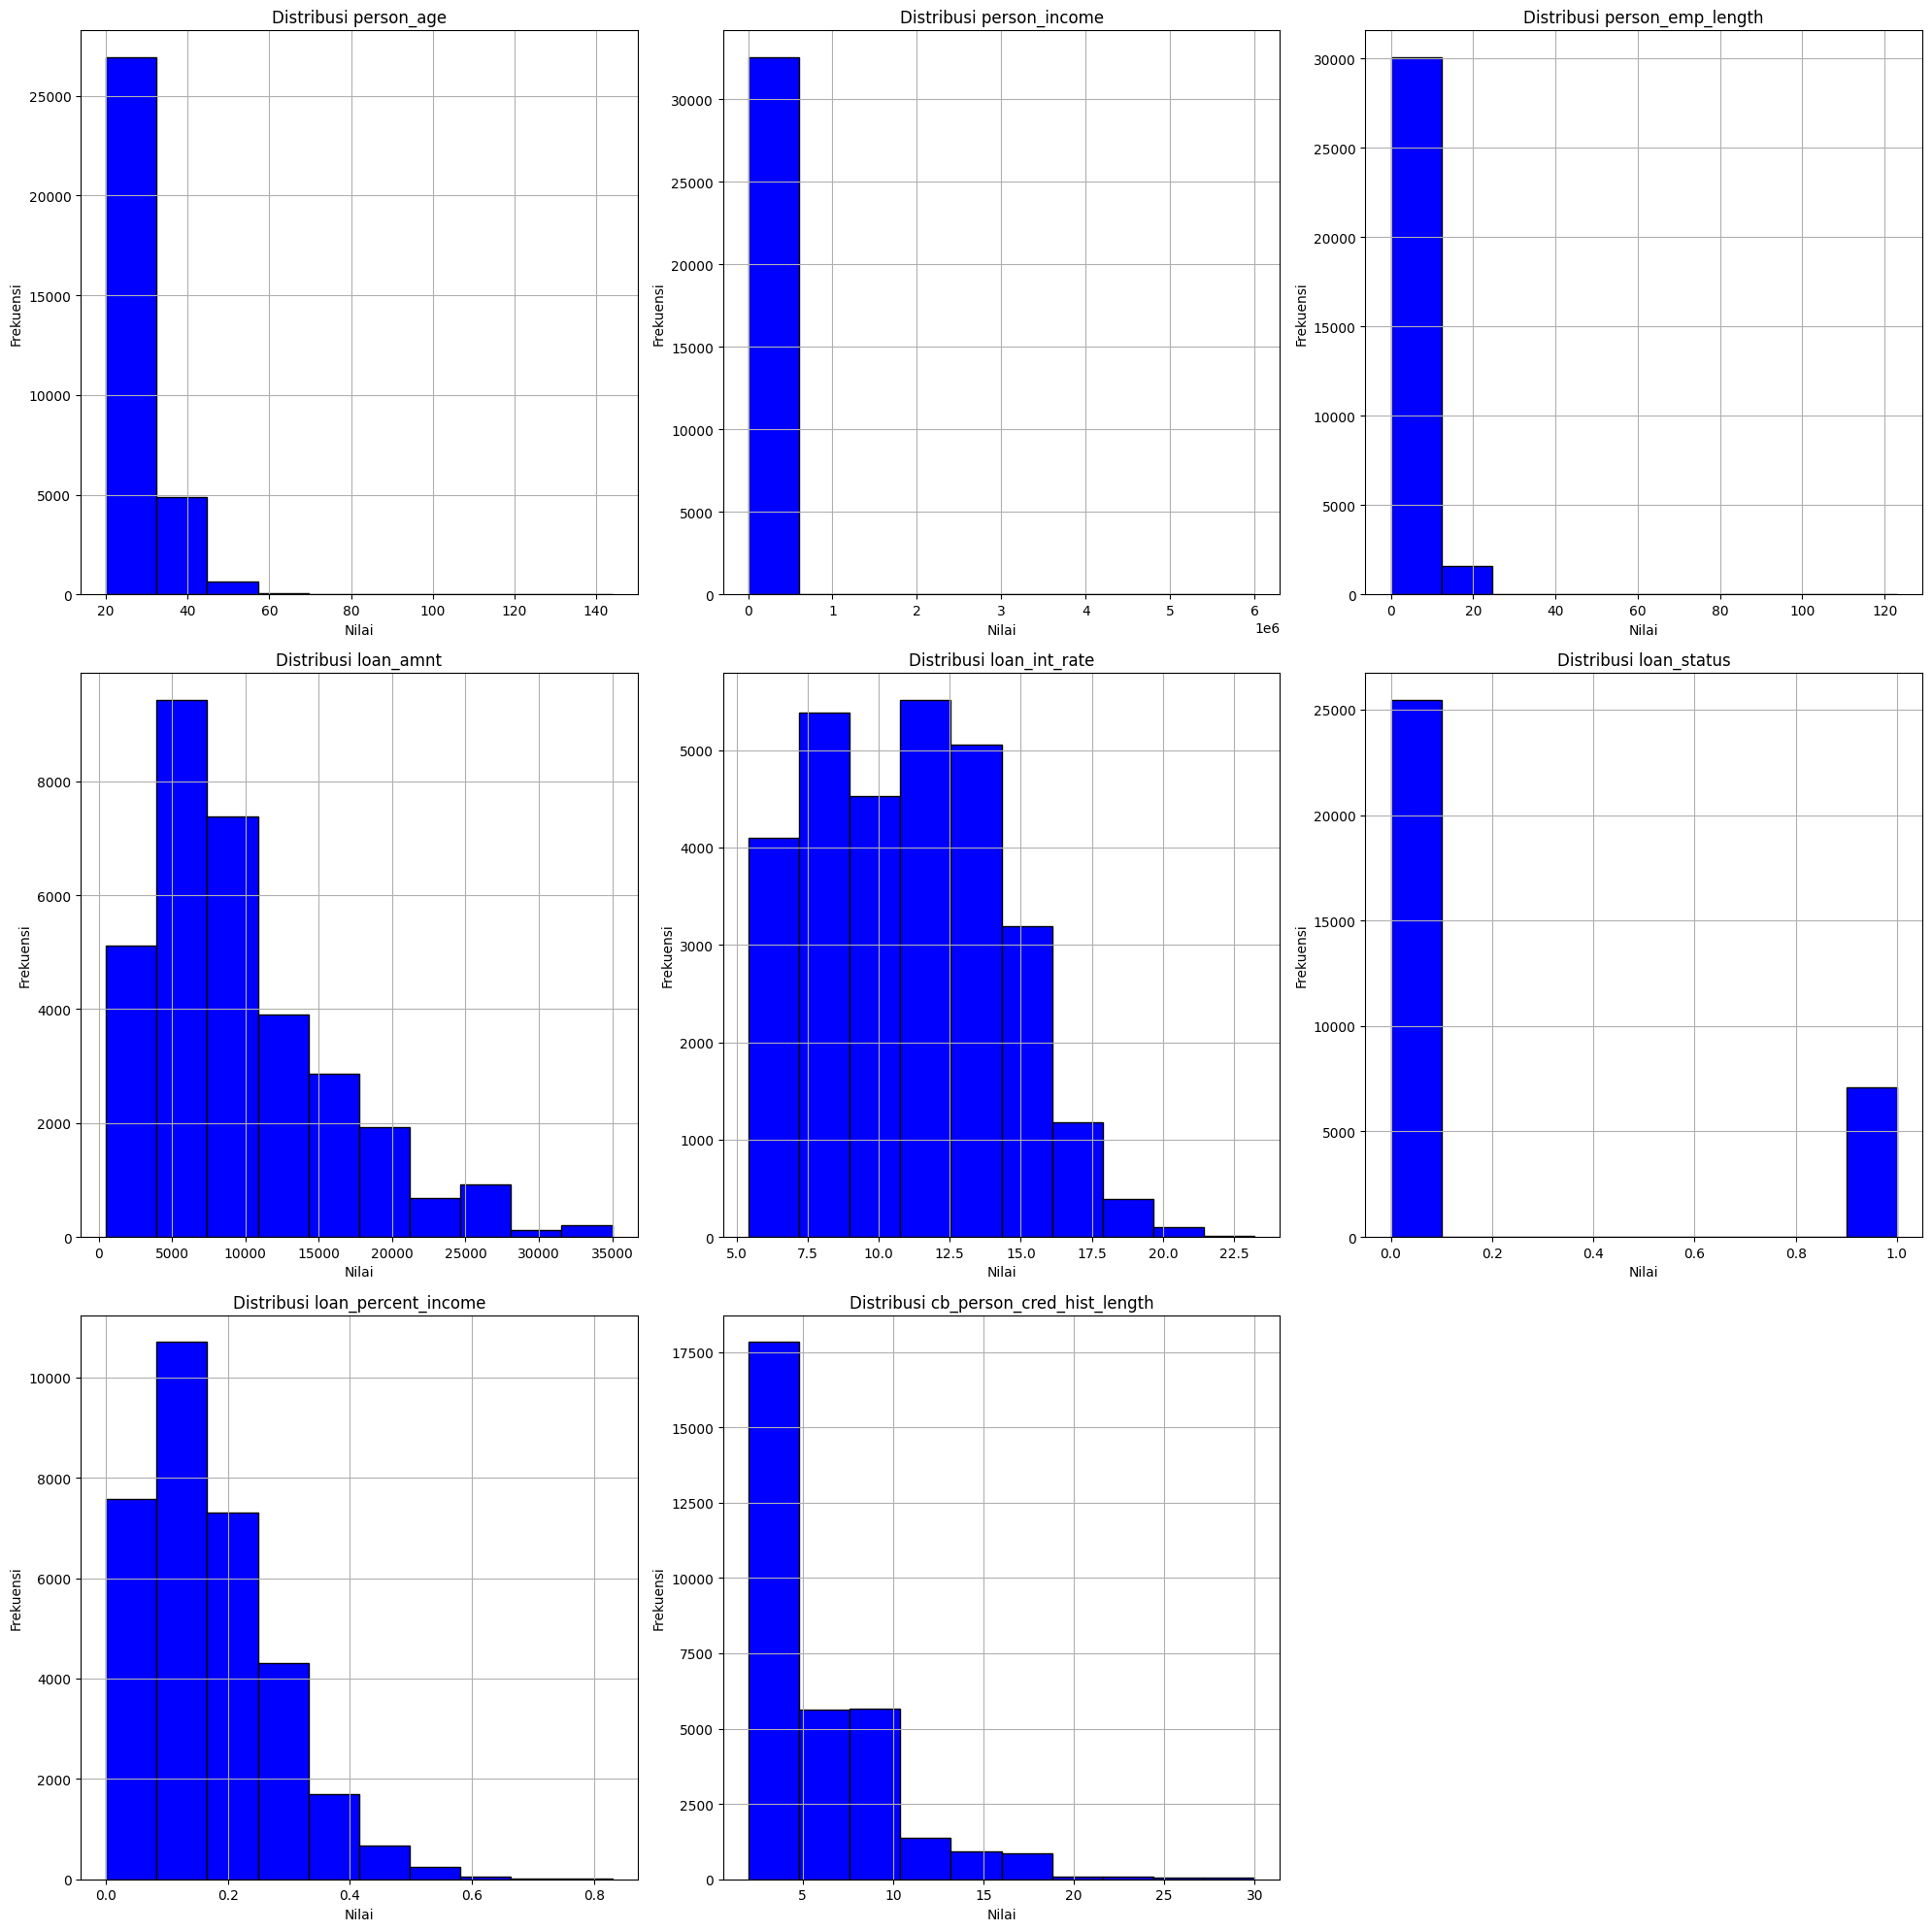

In [7]:
axes = df.hist(figsize=(20, 20), color='blue', edgecolor='black')

for ax in axes.flatten():
    ax.set_xlabel("Nilai")
    ax.set_ylabel("Frekuensi")
    ax.set_title(f"Distribusi {ax.get_title()}")

plt.tight_layout()
plt.show()

Kemudian distribusi untuk kolom bernilai Kategorikal

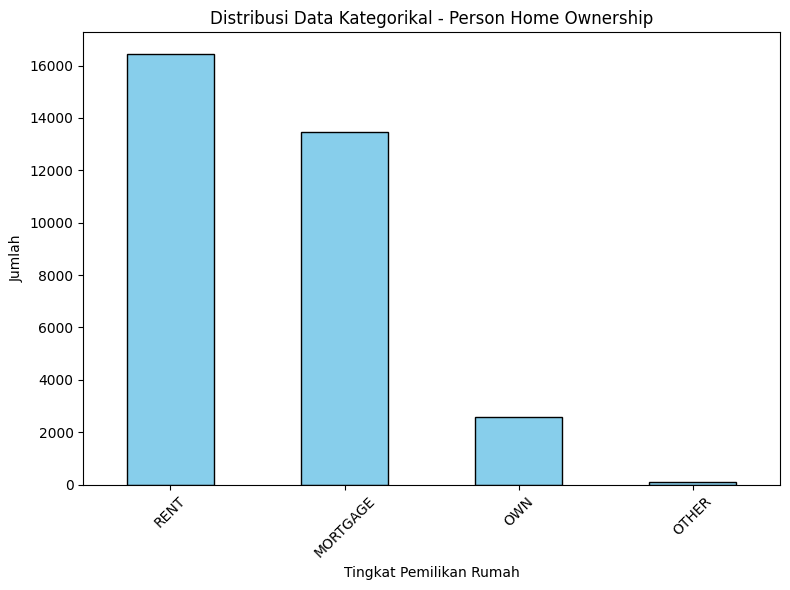

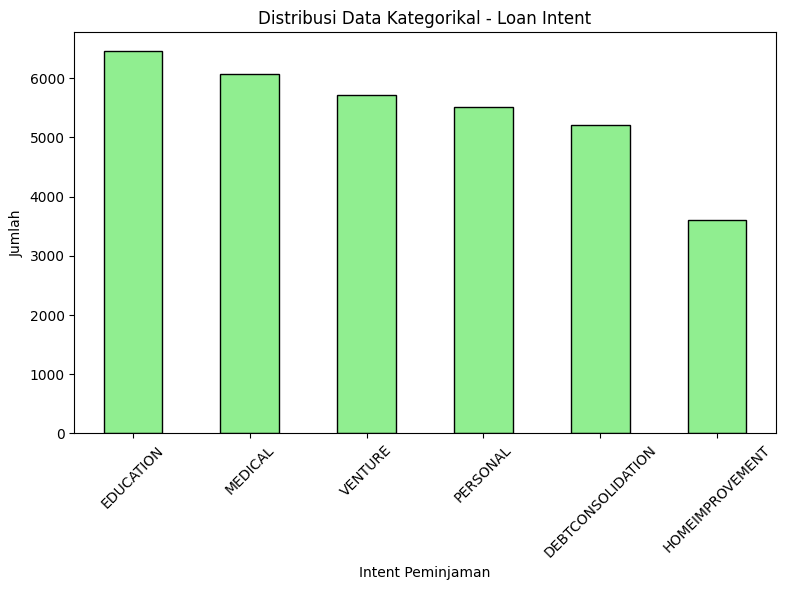

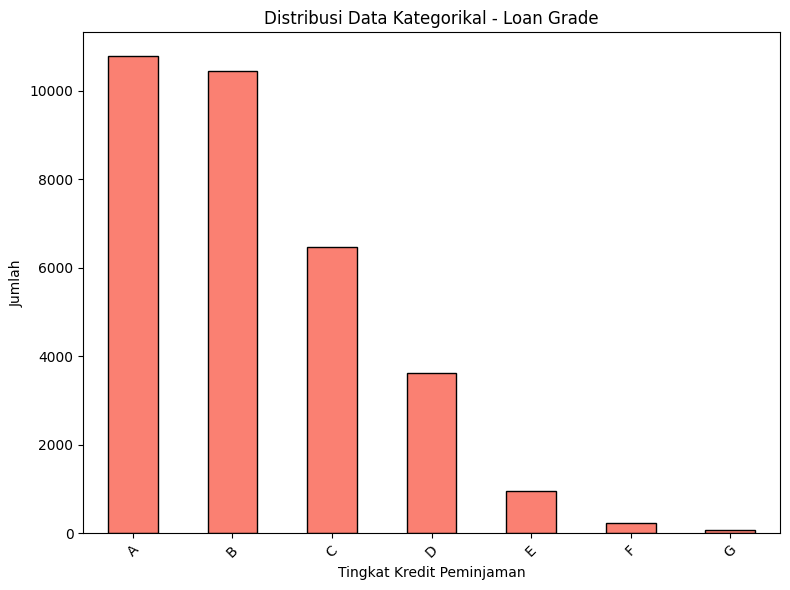

In [8]:
# Distribusi data kategorikal kolom `person_home_ownership`
home_ownership_counts = df['person_home_ownership'].value_counts()
plt.figure(figsize=(8, 6))
home_ownership_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Tingkat Pemilikan Rumah')
plt.ylabel('Jumlah')
plt.title('Distribusi Data Kategorikal - Person Home Ownership')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribusi data kategorikal kolom `loan_intent`
loan_intent_counts = df['loan_intent'].value_counts()
plt.figure(figsize=(8, 6))
loan_intent_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.xlabel('Intent Peminjaman')
plt.ylabel('Jumlah')
plt.title('Distribusi Data Kategorikal - Loan Intent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribusi data kategorikal kolom `loan_grade	`
loan_grade_counts = df['loan_grade'].value_counts()
plt.figure(figsize=(8, 6))
loan_grade_counts.plot(kind='bar', color='salmon', edgecolor='black')
plt.xlabel('Tingkat Kredit Peminjaman')
plt.ylabel('Jumlah')
plt.title('Distribusi Data Kategorikal - Loan Grade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Selanjutnya adalah melihat korelasi matriks untuk kolom numerikal

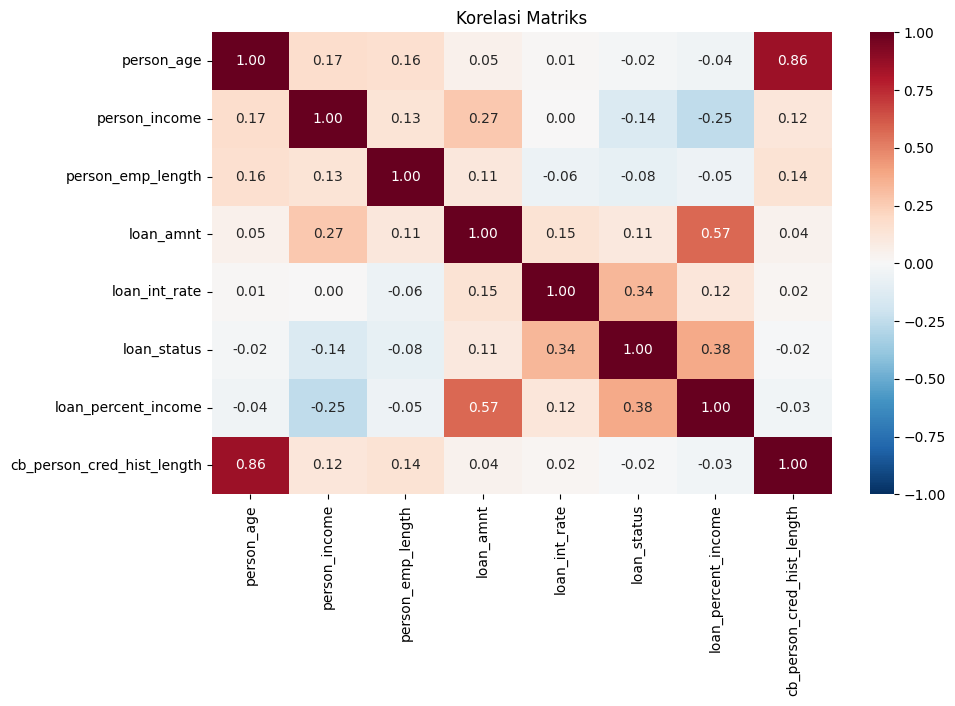

In [9]:
numerical_cols = df.select_dtypes(include=['number']).columns

#Hitung matriks korelasi
correlation = df[numerical_cols].corr()

#Buat plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelasi Matriks')
plt.show()

Dari korelasi matriks di atas, diperoleh informasi yaitu:
- terdapat korelasi yang kuat antara kolom person_age dan cb_person_cred_hist_length (0.86) semakin tua usia seseorang, semakin lama riwayat kreditnya. 
- Kemudian ada juga korelasi antara kolom loan_status dengan loan_percent_income (0.38) semakin besar persentase pinjaman terhadap pendapatan, risiko gagal bayar semakin tinggi. 
- Kolom loan_status dengan loan_int_rate (0.34) semakin tinggi suku bunga pinjaman, semakin tinggi pula risiko gagal bayar. 
- Kolom loan_status dan person_income (-0.14) semakin tinggi pendapatan seseorang, risiko gagal bayarnya sedikit menurun. - Ada juga loan_amnt dan loan_percent_income (0.57) semakin besar jumlah pinjaman yang diajukan, otomatis persentase pinjaman terhadap pendapatan juga ikut membesar.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Pada bagian ini, data dengan nilai kosong dan duplikat dihapus

In [10]:
df_clean = df.dropna()
print(df_clean.isnull().sum())

df_clean = df_clean.drop_duplicates()
print(df_clean.duplicated().sum())


person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
0


Kemudian data outlier pada kolom person_income dibersihkan. Data di luar batas bawah dan batas atas akan dihapus.

In [11]:
# Hitung Q1 (kuartil 25%) dan Q3 (kuartil 75%)
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)

# Hitung selisih kuartil (IQR)
IQR = Q3 - Q1

# Tentukan batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Hapus baris yang berada di luar batas tersebut
df_clean = df[(df['person_income'] >= batas_bawah) & (df['person_income'] <= batas_atas)]

Kemudian, pada kolom person_age dan person_emp_length juga dibersihkan

In [12]:
df_clean = df[df['person_age'] <= 80].copy()
df_clean = df_clean[df_clean['person_emp_length'] <= 60].copy()

Terakhir ada mengatasi nilai outlier pada kolom loan_int_rate dengan nilai median

In [13]:
df_clean.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,31677.000000,3.167700e+04,31677,31677.000000,31677,31677,31677.000000,28631.000000,31677.000000,31677.000000,31677,31677.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16071,NaN,6288,10369,NaN,NaN,NaN,NaN,26049,NaN
mean,27.726805,6.649055e+04,NaN,4.782271,NaN,NaN,9660.051457,11.039825,0.215456,0.169609,NaN,5.807968
std,6.194392,5.276968e+04,NaN,4.034989,NaN,NaN,6334.535354,3.229398,0.411145,0.106270,NaN,4.056804
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.939600e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.600000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,8.000000e+04,NaN,7.000000,NaN,NaN,12500.000000,13.480000,0.000000,0.230000,NaN,8.000000


In [14]:
y = df_clean['loan_status']

numerik = df_clean.select_dtypes(include=['number']).columns.tolist()

if 'loan_status' in numerik:
    numerik.remove('loan_status')

scaler = StandardScaler()
scaled_arr = scaler.fit_transform(df_clean[numerik])

scaled_df = pd.DataFrame(scaled_arr, columns=numerik, index=df_clean.index)
df_clean[numerik] = scaled_df

df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,-1.085968,-1.078109,OWN,0.053961,EDUCATION,B,-1.367139,0.031020,0,-0.655028,N,-0.938677
2,-0.440212,-1.078109,MORTGAGE,-0.937383,MEDICAL,C,-0.656736,0.566733,1,3.767730,N,-0.692173
3,-0.763090,-0.018771,RENT,-0.193875,MEDICAL,C,4.000348,1.297532,1,3.391325,N,-0.938677
4,-0.601651,-0.229123,RENT,0.797469,MEDICAL,C,4.000348,1.000258,1,3.579527,Y,-0.445670
5,-1.085968,-1.072423,OWN,-0.689547,VENTURE,A,-1.130338,-1.207622,1,0.756490,N,-0.938677


In [15]:
df_clean['person_home_ownership'] = df_clean['person_home_ownership'].astype('category').cat.codes
df_clean['loan_intent'] = df_clean['loan_intent'].astype('category').cat.codes
df_clean['loan_grade'] = df_clean['loan_grade'].astype('category').cat.codes
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].astype('category').cat.codes

df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,-1.085968,-1.078109,2,0.053961,1,1,-1.367139,0.031020,0,-0.655028,0,-0.938677
2,-0.440212,-1.078109,0,-0.937383,3,2,-0.656736,0.566733,1,3.767730,0,-0.692173
3,-0.763090,-0.018771,3,-0.193875,3,2,4.000348,1.297532,1,3.391325,0,-0.938677
4,-0.601651,-0.229123,3,0.797469,3,2,4.000348,1.000258,1,3.579527,1,-0.445670
5,-1.085968,-1.072423,2,-0.689547,5,0,-1.130338,-1.207622,1,0.756490,0,-0.938677


In [16]:
df_clean.to_csv(r"D:/winda's Project/Belajar Dicoding/Pijak By Dicoding/Submission/SML/credit_risk_dataset_preprocessing.csv", index=False)
print("Data telah disimpan ke credit_risk_dataset_preprocessing.csv")

Data telah disimpan ke credit_risk_dataset_preprocessing.csv
